<a href="https://colab.research.google.com/github/ashtonefrazier2424/ThinkPythonAssignments2026/blob/main/Week15_2/Week15_DreamProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit
Choose an option: 5

📈 Progress for 2026:
Books read: 11/65
Progress: 16.92%
Books remaining: 54

--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit
Choose an option: 1
Title: Mistakes Were Made
Author: Lucy Score
Genre: Romance
Pages: 550
Start date (YYYY-MM-DD): 2026-04-04
End date (YYYY-MM-DD): 2026-04-06
Rating (1-5): 5
✅ Book added!


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit
Choose an option: 3

📚 Recommended Genres Based on Your Taste:
- Try more Historical Fiction books!
- Try more Mystery books!
- Try more Thriller books!

💡 Tip: Look for books in these genres online or expand this with an API later.

---

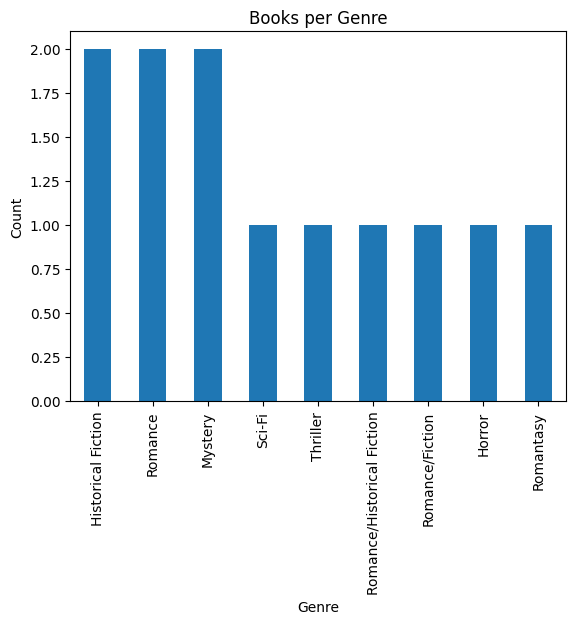


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

conn = sqlite3.connect("/content/drive/MyDrive/reading_tracker.db")
cursor = conn.cursor()

# Install libraries (only needed in Colab)
!pip install pandas matplotlib

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Connect to database (creates file)
conn = sqlite3.connect("reading_tracker.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS books (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    author TEXT,
    genre TEXT,
    pages INTEGER,
    start_date TEXT,
    end_date TEXT,
    rating REAL
)
""")
conn.commit()

cursor.execute("""
CREATE TABLE IF NOT EXISTS goals (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    target_books INTEGER,
    year INTEGER
)
""")
conn.commit()

def get_int(prompt, min_value=None, max_value=None):
    while True:
        try:
            value = int(input(prompt))
            if min_value is not None and value < min_value:
                print(f"Value must be at least {min_value}")
                continue
            if max_value is not None and value > max_value:
                print(f"Value must be at most {max_value}")
                continue
            return value
        except ValueError:
            print("❌ Please enter a valid number.")


def get_float(prompt, min_value=None, max_value=None):
    while True:
        try:
            value = float(input(prompt))
            if min_value is not None and value < min_value:
                print(f"Value must be at least {min_value}")
                continue
            if max_value is not None and value > max_value:
                print(f"Value must be at most {max_value}")
                continue
            return value
        except ValueError:
            print("❌ Please enter a valid number.")


def get_non_empty(prompt):
    while True:
        value = input(prompt).strip()
        if value:
            return value
        print("❌ This field cannot be empty.")


def get_date(prompt):
    while True:
        value = input(prompt)
        try:
            datetime.strptime(value, "%Y-%m-%d")
            return value
        except ValueError:
            print("❌ Invalid date format. Use YYYY-MM-DD.")


# -------- ADD BOOK FUNCTION --------
def add_book():
    title = get_non_empty("Title: ")
    author = get_non_empty("Author: ")
    genre = get_non_empty("Genre: ")
    pages = get_int("Pages: ", min_value=1)

    while True:
        start_date = get_date("Start date (YYYY-MM-DD): ")
        end_date = get_date("End date (YYYY-MM-DD): ")

        start_dt = datetime.strptime(start_date, "%Y-%m-%d")
        end_dt = datetime.strptime(end_date, "%Y-%m-%d")

        if end_dt >= start_dt:
            break
        else:
            print("❌ End date must be after start date.")

    rating = get_float("Rating (1-5): ", min_value=1, max_value=5)

    cursor.execute("""
    INSERT INTO books (title, author, genre, pages, start_date, end_date, rating)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (title, author, genre, pages, start_date, end_date, rating))

    conn.commit()
    print("✅ Book added!\n")


# -------- VIEW STATS FUNCTION --------
def view_stats():
    df = pd.read_sql_query("SELECT * FROM books", conn)

    # ✅ No data check
    if df.empty:
        print("📭 No data yet. Try adding a book first!")
        return

    # ✅ Convert dates safely
    df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
    df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

    # ❌ Drop rows with invalid dates
    df = df.dropna(subset=["start_date", "end_date"])

    if df.empty:
        print("⚠️ All entries have invalid dates.")
        return

    # ✅ Calculate days safely
    df["days"] = (df["end_date"] - df["start_date"]).dt.days + 1

    # ❌ Remove invalid durations
    df = df[df["days"] > 0]

    if df.empty:
        print("⚠️ No valid reading durations found.")
        return

    # ✅ Calculate reading speed
    df["speed"] = df["pages"] / df["days"]

    # ✅ Stats
    total_pages = df["pages"].sum()
    avg_rating = df["rating"].mean()
    avg_speed = df["speed"].mean()

    print("\n📊 Reading Stats:")
    print(f"Total pages read: {total_pages}")
    print(f"Average rating: {avg_rating:.2f}")
    print(f"Average reading speed (pages/day): {avg_speed:.2f}")

    # ✅ Genre chart (safe)
    genre_counts = df["genre"].value_counts()

    if not genre_counts.empty:
        genre_counts.plot(kind='bar')
        plt.title("Books per Genre")
        plt.xlabel("Genre")
        plt.ylabel("Count")
        plt.show()
def recommend_books():
    df = pd.read_sql_query("SELECT * FROM books", conn)

    if df.empty:
        print("No data yet.")
        return

    # Focus on highly rated books
    liked = df[df["rating"] >= 4]

    if liked.empty:
        print("Add some highly rated books first!")
        return

    top_genres = liked["genre"].value_counts().head(3)

    print("\n📚 Recommended Genres Based on Your Taste:")
    for genre in top_genres.index:
        print(f"- Try more {genre} books!")

    print("\n💡 Tip: Look for books in these genres online or expand this with an API later.")


def set_goal():
    year = get_int("Enter year: ", min_value=2000, max_value=2100)
    target = get_int("How many books do you want to read? ", min_value=1)

    cursor.execute("INSERT INTO goals (target_books, year) VALUES (?, ?)", (target, year))
    conn.commit()

    print("🎯 Goal saved!")

def view_progress():
    df = pd.read_sql_query("SELECT * FROM books", conn)
    goals = pd.read_sql_query("SELECT * FROM goals ORDER BY id DESC LIMIT 1", conn)

    if goals.empty:
        print("No goal set yet.")
        return

    goal = goals.iloc[0]["target_books"]
    year = goals.iloc[0]["year"]

    df["end_date"] = pd.to_datetime(df["end_date"])
    df_year = df[df["end_date"].dt.year == year]

    books_read = len(df_year)

    progress = (books_read / goal) * 100 if goal > 0 else 0

    print(f"\n📈 Progress for {year}:")
    print(f"Books read: {books_read}/{goal}")
    print(f"Progress: {progress:.2f}%")

    remaining = goal - books_read
    print(f"Books remaining: {max(0, remaining)}")

# -------- MAIN MENU --------
def menu():
    while True:
        print("\n--- Reading Tracker ---")
        print("1. Add Book")
        print("2. View Stats")
        print("3. Recommend Books")
        print("4. Set Reading Goal")
        print("5. View Progress")
        print("6. Exit")

        choice = input("Choose an option: ")

        if choice == "1":
            add_book()
        elif choice == "2":
            view_stats()
        elif choice == "3":
            recommend_books()
        elif choice == "4":
            set_goal()
        elif choice == "5":
            view_progress()
        elif choice == "6":
            print("Goodbye!")
            break
        else:
            print("Invalid choice.")

menu()